# Simulation Validation: PCA-based Data Generation

This notebook validates the PCA simulation method (`dat_generator_pca`) by comparing
statistical properties of simulated datasets against the real datasets they were
generated from.

For each combination of sample size (n) and feature count (p) we generate paired
synthetic source and target datasets and measure how faithfully the simulation
preserves:

| Property | Metric |
|---|---|
| **Feature mean distribution** | KS statistic + p-value comparing the *distribution* of per-feature means |
| **Feature variance distribution** | KS statistic + p-value comparing the *distribution* of per-feature variances |
| **Pairwise correlation distribution** | KS statistic + p-value comparing the *distribution* of pairwise correlations |
| **Marginal distributions** | Mean KS statistic across per-feature marginal tests; % features passing |
| **Correlation matrix distance** | Frobenius norm ‖R_real − R_sim‖_F / p |

KS statistics are used throughout because they compare distributions directly
without requiring feature-to-feature alignment between real and simulated data.

## Imports and settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from scipy.linalg import norm
from itertools import product

from omicstl.simulation_utils.data_generation import generate_synth_data_pca

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = {'source': '#1976D2', 'target': '#E64A19'}
REAL_COLOR = '#555555'

## Load real datasets

Both files should contain feature-only matrices (no response column) with samples
as rows and features as columns.

In [2]:
source_real = pd.read_csv("data/source_dset.csv", index_col=0)
target_real = pd.read_csv("data/target_dset.csv", index_col=0)

# If a response column is present (named 'response' or first column is non-numeric),
# drop it so we work with features only.
for _name, _df in [("source", source_real), ("target", target_real)]:
    if "response" in _df.columns:
        _df.drop(columns=["response"], inplace=True)

print(f"Source real:  {source_real.shape[0]} samples × {source_real.shape[1]} features")
print(f"Target real:  {target_real.shape[0]} samples × {target_real.shape[1]} features")
display(source_real.describe().loc[["mean", "std"]].round(3))

Source real:  358 samples × 476 features
Target real:  240 samples × 476 features


,RS30_HUMAN,EIF3I_HUMAN,RL24_HUMAN,ARPC2_HUMAN,RUVB1_HUMAN,TEBP_HUMAN,PPGB_HUMAN,KPYM_HUMAN,PRDX5_HUMAN,PDIA1_HUMAN,...,RL30_HUMAN,TMM43_HUMAN,SMD3_HUMAN,VDAC2_HUMAN,RL27A_HUMAN,RAB5C_HUMAN,CPNE1_HUMAN,SRSF3_HUMAN,FKB1A_HUMAN,SC61B_HUMAN
mean,1.345,0.733,2.271,1.461,1.050,2.821,0.532,6.464,3.356,4.204,...,3.380,1.082,2.148,4.119,3.224,1.166,1.053,2.490,3.976,1.256
std,1.201,0.663,1.108,1.085,0.747,0.912,0.939,1.699,1.633,0.521,...,0.853,0.608,0.725,0.592,0.594,0.687,1.711,1.284,1.713,1.299


## Simulation grid

We vary:
- **n_source** – number of simulated source samples
- **n_target** – number of simulated target samples (small values stress-test the shrinkage covariance estimator)
- **p** – number of output features (≤ real feature count → exact subsampling; > real → structured LC)

In [3]:
n_source_list = [100, 200]               # simulated source sample sizes
n_target_list = [10, 25, 50, 100]       # simulated target sample sizes
p_list        = [100, 200]               # output feature counts

p_real = source_real.shape[1]
for p in p_list:
    if p > p_real:
        print(f"  Warning: p={p} > p_real={p_real}; LC mixing (Option B) will be used for this setting.")

scenarios = [
    {"n_source": ns, "n_target": nt, "p": pf,
     "label": f"ns={ns} nt={nt} p={pf}"}
    for ns, nt, pf in product(n_source_list, n_target_list, p_list)
]
print(f"{len(scenarios)} scenarios defined")
pd.DataFrame(scenarios)

16 scenarios defined


,n_source,n_target,p,label
0,100,10,100,ns=100 nt=10 p=100
1,100,10,200,ns=100 nt=10 p=200
2,100,25,100,ns=100 nt=25 p=100
3,100,25,200,ns=100 nt=25 p=200
4,100,50,100,ns=100 nt=50 p=100
5,100,50,200,ns=100 nt=50 p=200
6,100,100,100,ns=100 nt=100 p=100
7,100,100,200,ns=100 nt=100 p=200
8,200,10,100,ns=200 nt=10 p=100
9,200,10,200,ns=200 nt=10 p=200


## Statistical helper functions

In [4]:
def align(real_df: pd.DataFrame, sim_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Align on common columns (Option A) or positionally (Option B)."""
    common = [c for c in sim_df.columns if c in real_df.columns]
    if common:
        return real_df[common], sim_df[common]
    return real_df.iloc[:, :sim_df.shape[1]], sim_df


def compute_stats(real_df: pd.DataFrame, sim_df: pd.DataFrame) -> dict:
    """Compare real vs simulated using distribution-level KS tests.

    KS tests compare the *distribution* of per-feature means, variances, and
    pairwise correlations — no feature-to-feature alignment required.
    """
    real = real_df.values.astype(float)
    sim  = sim_df.values.astype(float)
    p    = real.shape[1]

    real_means = real.mean(axis=0)
    sim_means  = sim.mean(axis=0)
    real_vars  = real.var(axis=0, ddof=1)
    sim_vars   = sim.var(axis=0, ddof=1)

    # Per-feature marginal KS (each feature's full distribution)
    feat_ks      = [ks_2samp(real[:, j], sim[:, j]) for j in range(p)]
    feat_ks_stat = np.array([r.statistic for r in feat_ks])
    feat_ks_pval = np.array([r.pvalue   for r in feat_ks])

    # Correlation upper triangles
    real_cor = np.corrcoef(real, rowvar=False)
    sim_cor  = np.corrcoef(sim,  rowvar=False)
    tri      = np.triu_indices(p, k=1)
    real_tri = real_cor[tri]
    sim_tri  = sim_cor[tri]

    # Distribution-level KS: does the simulation reproduce the same
    # *spread / shape* of means / variances / correlations across features?
    mean_ks = ks_2samp(real_means, sim_means)
    var_ks  = ks_2samp(real_vars,  sim_vars)
    cor_ks  = ks_2samp(real_tri,   sim_tri)

    frob = norm(real_cor - sim_cor, 'fro') / p

    return dict(
        # raw arrays for plotting
        real_means=real_means, sim_means=sim_means,
        real_vars=real_vars,   sim_vars=sim_vars,
        real_tri=real_tri,     sim_tri=sim_tri,
        real_cor=real_cor,     sim_cor=sim_cor,
        # per-feature marginal KS
        ks_stats=feat_ks_stat, ks_pvals=feat_ks_pval,
        feat_ks_mean=feat_ks_stat.mean(),
        frac_pass=np.mean(feat_ks_pval > 0.05),
        # distribution-level KS (primary metrics)
        mean_ks=mean_ks.statistic, mean_ks_p=mean_ks.pvalue,
        var_ks=var_ks.statistic,   var_ks_p=var_ks.pvalue,
        cor_ks=cor_ks.statistic,   cor_ks_p=cor_ks.pvalue,
        frob=frob,
    )

## Run simulations

For each scenario we:
1. Simulate paired source and target data using `generate_synth_data_pca`.
2. Align simulated features to the corresponding real features.
3. Compute all comparison statistics.

In [5]:
records = []

for sc in scenarios:
    ns, nt, pf, lbl = sc["n_source"], sc["n_target"], sc["p"], sc["label"]
    print(f"Simulating {lbl} ...", end=" ", flush=True)

    synth_src, synth_tgt = generate_synth_data_pca(
        source_data=source_real,
        target_data=target_real,
        n_output_samps_source=ns,
        n_output_samps_target=nt,
        n_output_features=pf,
    )

    real_src_al, synth_src_al = align(source_real, synth_src)
    real_tgt_al, synth_tgt_al = align(target_real, synth_tgt)

    src_stats = compute_stats(real_src_al, synth_src_al)
    tgt_stats = compute_stats(real_tgt_al, synth_tgt_al)

    records.append({
        **sc,
        "src_stats": src_stats, "tgt_stats": tgt_stats,
        "synth_src": synth_src_al, "synth_tgt": synth_tgt_al,
        "real_src":  real_src_al,  "real_tgt":  real_tgt_al,
    })
    print(
        f"src: mean_ks={src_stats['mean_ks']:.3f} var_ks={src_stats['var_ks']:.3f} cor_ks={src_stats['cor_ks']:.3f}  |  "
        f"tgt: mean_ks={tgt_stats['mean_ks']:.3f} var_ks={tgt_stats['var_ks']:.3f} cor_ks={tgt_stats['cor_ks']:.3f}"
    )

print("\nAll simulations complete.")

Simulating ns=100 nt=10 p=100 ... src: mean_ks=0.061 var_ks=0.101 cor_ks=0.022  |  tgt: mean_ks=0.051 var_ks=0.202 cor_ks=0.082
Simulating ns=100 nt=10 p=200 ... src: mean_ks=0.051 var_ks=0.051 cor_ks=0.069  |  tgt: mean_ks=0.036 var_ks=0.113 cor_ks=0.110
Simulating ns=100 nt=25 p=100 ... src: mean_ks=0.031 var_ks=0.134 cor_ks=0.036  |  tgt: mean_ks=0.041 var_ks=0.072 cor_ks=0.068
Simulating ns=100 nt=25 p=200 ... src: mean_ks=0.025 var_ks=0.152 cor_ks=0.028  |  tgt: mean_ks=0.035 var_ks=0.086 cor_ks=0.057
Simulating ns=100 nt=50 p=100 ... src: mean_ks=0.070 var_ks=0.100 cor_ks=0.028  |  tgt: mean_ks=0.060 var_ks=0.140 cor_ks=0.025
Simulating ns=100 nt=50 p=200 ... src: mean_ks=0.026 var_ks=0.056 cor_ks=0.015  |  tgt: mean_ks=0.031 var_ks=0.077 cor_ks=0.019
Simulating ns=100 nt=100 p=100 ... src: mean_ks=0.081 var_ks=0.071 cor_ks=0.039  |  tgt: mean_ks=0.040 var_ks=0.061 cor_ks=0.017
Simulating ns=100 nt=100 p=200 ... src: mean_ks=0.061 var_ks=0.041 cor_ks=0.019  |  tgt: mean_ks=0.025 

## Summary metrics table

In [6]:
def fmt_p(p):
    if p < 0.001: return "<0.001"
    return f"{p:.3f}"

rows = []
for rec in records:
    for domain, key in [("source", "src_stats"), ("target", "tgt_stats")]:
        s = rec[key]
        rows.append({
            "n_source": rec["n_source"], "n_target": rec["n_target"], "p": rec["p"],
            "domain":        domain,
            "mean KS":       round(s["mean_ks"],    3),
            "mean KS p":     fmt_p(s["mean_ks_p"]),
            "var KS":        round(s["var_ks"],     3),
            "var KS p":      fmt_p(s["var_ks_p"]),
            "cor KS":        round(s["cor_ks"],     3),
            "cor KS p":      fmt_p(s["cor_ks_p"]),
            "Frob/p":        round(s["frob"],       3),
            "feat KS (mean)": round(s["feat_ks_mean"], 3),
            "% pass KS":     round(s["frac_pass"] * 100, 1),
        })

summary = pd.DataFrame(rows)
display(
    summary.style
    .background_gradient(subset=["mean KS", "var KS", "cor KS"], cmap="YlOrRd", vmin=0, vmax=1)
    .background_gradient(subset=["Frob/p", "feat KS (mean)"], cmap="YlOrRd")
    .background_gradient(subset=["% pass KS"], cmap="YlGn", vmin=0, vmax=100)
    .format(precision=3)
)

,n_source,n_target,p,domain,mean KS,mean KS p,var KS,var KS p,cor KS,cor KS p,Frob/p,feat KS (mean),% pass KS
0,100,10,100,source,0.061,0.994,0.101,0.696,0.022,0.181,0.076,0.143,61.600
1,100,10,100,target,0.051,1.000,0.202,0.035,0.082,<0.001,0.267,0.273,92.900
2,100,10,200,source,0.051,0.960,0.051,0.960,0.069,<0.001,0.126,0.150,57.900
3,100,10,200,target,0.036,1.000,0.113,0.167,0.110,<0.001,0.299,0.266,95.400
4,100,25,100,source,0.031,1.000,0.134,0.350,0.036,0.005,0.113,0.147,59.800
5,100,25,100,target,0.041,1.000,0.072,0.964,0.068,<0.001,0.180,0.187,92.800
6,100,25,200,source,0.025,1.000,0.152,0.021,0.028,<0.001,0.090,0.163,48.500
7,100,25,200,target,0.035,1.000,0.086,0.460,0.057,<0.001,0.171,0.182,93.400
8,100,50,100,source,0.070,0.968,0.100,0.702,0.028,0.045,0.094,0.175,46.000
9,100,50,100,target,0.060,0.994,0.140,0.282,0.025,0.085,0.135,0.154,84.000


## Per-scenario diagnostic plots

Detailed scatter and density plots for a representative scenario.
Change `DIAG_IDX` to examine a different entry from the simulation grid.

In [7]:
# Pick a representative scenario (largest n_source, medium n_target)
DIAG_IDX = next(
    i for i, r in enumerate(records)
    if r["n_source"] == max(n_source_list) and r["n_target"] == sorted(n_target_list)[len(n_target_list)//2]
       and r["p"] == max(p_list)
)
rec = records[DIAG_IDX]
print(f"Diagnostic scenario: {rec['label']}")

Diagnostic scenario: ns=200 nt=50 p=200


### Mean and variance fidelity

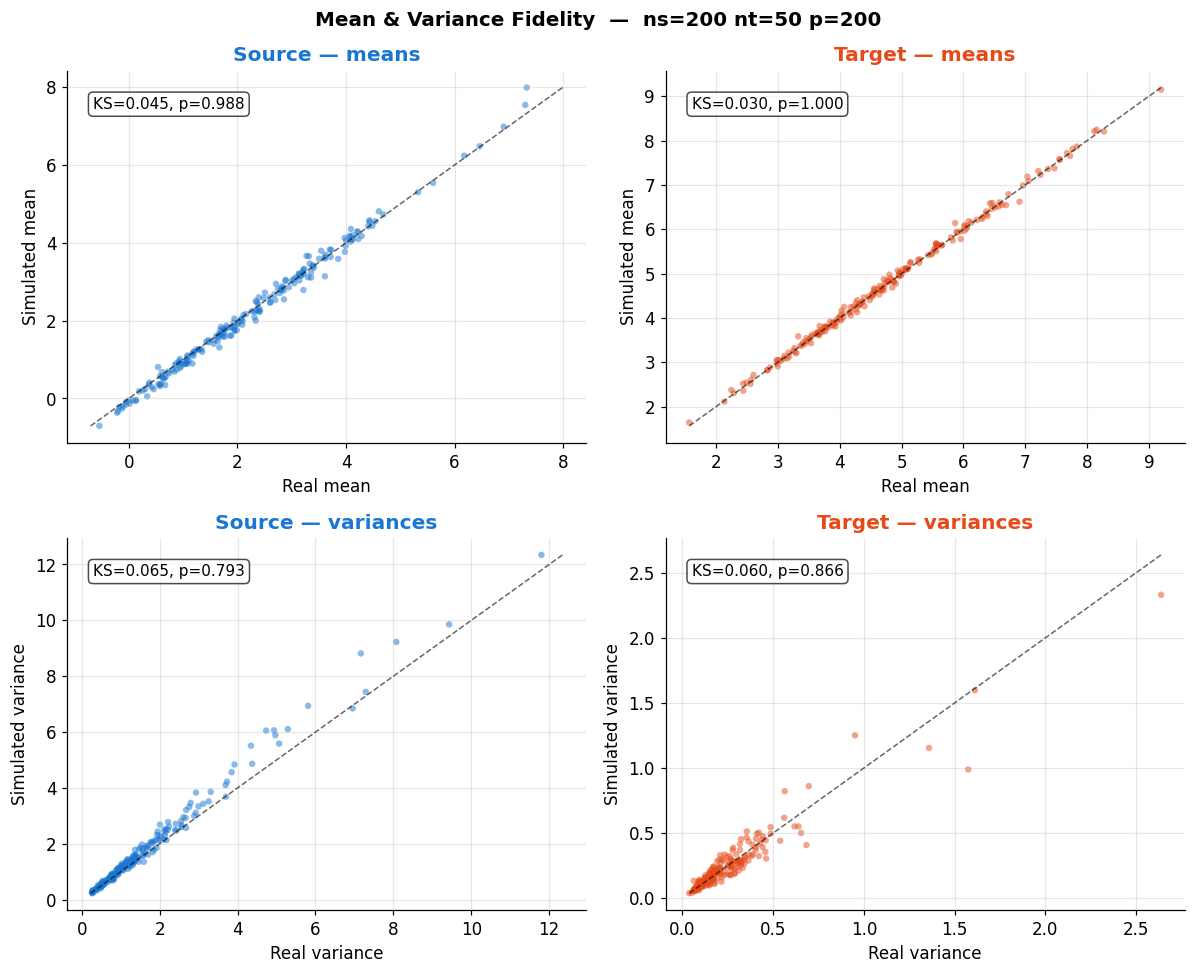

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle(f"Mean & Variance Fidelity  —  {rec['label']}", fontsize=13, fontweight='bold')

panels = [
    ("Source", rec["src_stats"], PALETTE["source"]),
    ("Target", rec["tgt_stats"], PALETTE["target"]),
]

for col, (domain, s, color) in enumerate(panels):
    for row, (stat, xlabel, ylabel, ks_key, ks_p_key) in enumerate([
        ("means", "Real mean",     "Simulated mean",     "mean_ks", "mean_ks_p"),
        ("vars",  "Real variance", "Simulated variance", "var_ks",  "var_ks_p"),
    ]):
        ax = axes[row, col]
        rx = s[f"real_{stat}"]
        sx = s[f"sim_{stat}"]
        ax.scatter(rx, sx, alpha=0.5, s=18, color=color, edgecolors='none')
        lims = [min(rx.min(), sx.min()), max(rx.max(), sx.max())]
        ax.plot(lims, lims, 'k--', lw=1, alpha=0.6, label='y = x')
        ks_val = s[ks_key]
        p_val  = s[ks_p_key]
        p_str  = "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
        ax.text(0.05, 0.93, f"KS={ks_val:.3f}, p={p_str}", transform=ax.transAxes,
                fontsize=10, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.set_title(f"{domain} — {'means' if stat=='means' else 'variances'}",
                     fontweight='bold', color=color)

plt.tight_layout()
plt.show()

### Pairwise correlation distribution

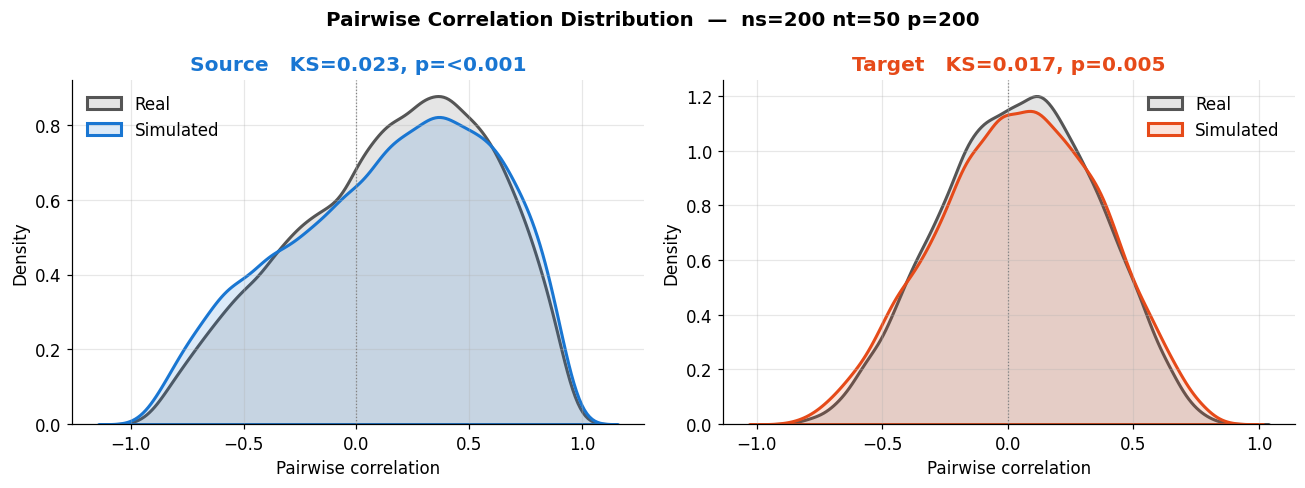

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(f"Pairwise Correlation Distribution  —  {rec['label']}",
             fontsize=13, fontweight='bold')

for ax, (domain, s, color) in zip(axes, panels):
    sns.kdeplot(s["real_tri"], ax=ax, color=REAL_COLOR, lw=2, label="Real", fill=True, alpha=0.15)
    sns.kdeplot(s["sim_tri"],  ax=ax, color=color,      lw=2, label="Simulated", fill=True, alpha=0.15)
    p_str = "<0.001" if s["cor_ks_p"] < 0.001 else f"{s['cor_ks_p']:.3f}"
    ax.set_xlabel("Pairwise correlation")
    ax.set_ylabel("Density")
    ax.set_title(f"{domain}   KS={s['cor_ks']:.3f}, p={p_str}", fontweight='bold', color=color)
    ax.legend(frameon=False)
    ax.axvline(0, color='gray', lw=0.8, ls=':')

plt.tight_layout()
plt.show()

### Distribution overlays: means, variances, and correlations

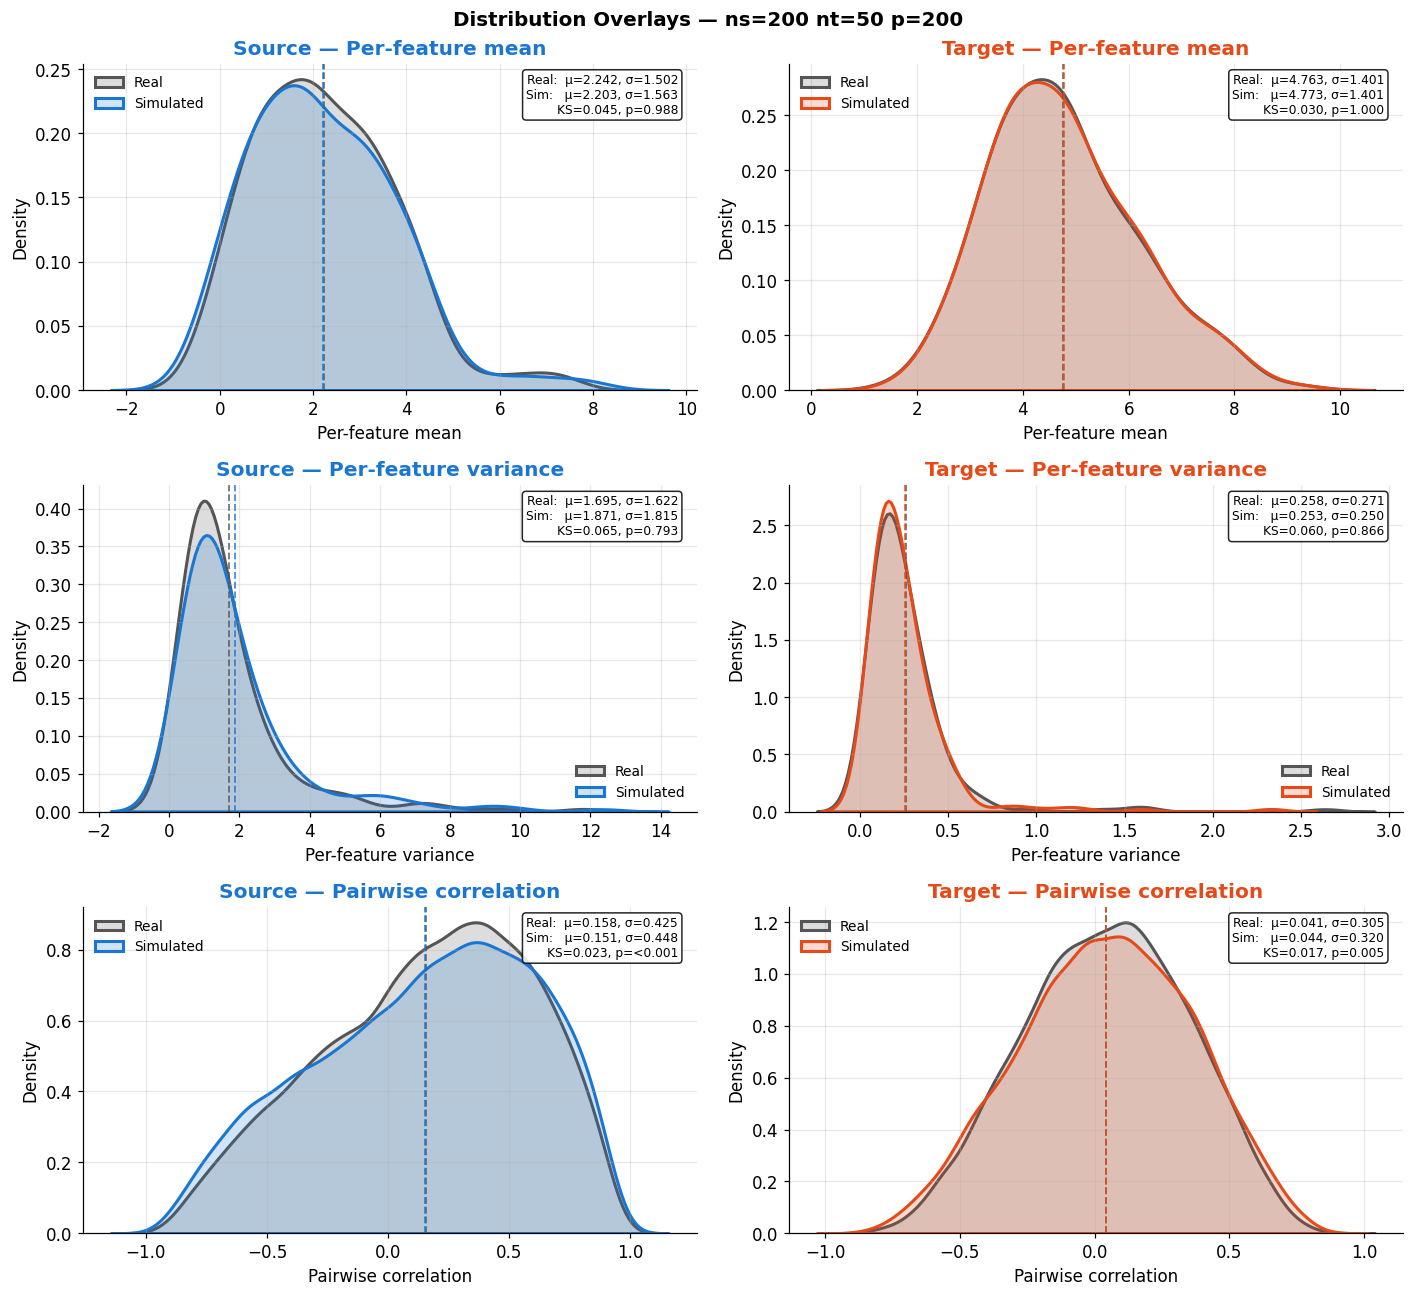

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(13, 12))
fig.suptitle(f"Distribution Overlays — {rec['label']}", fontsize=13, fontweight='bold')

row_cfg = [
    ("Per-feature mean",     "real_means", "sim_means", "mean_ks", "mean_ks_p"),
    ("Per-feature variance", "real_vars",  "sim_vars",  "var_ks",  "var_ks_p"),
    ("Pairwise correlation", "real_tri",   "sim_tri",   "cor_ks",  "cor_ks_p"),
]

for row_idx, (xlabel, real_key, sim_key, ks_key, p_key) in enumerate(row_cfg):
    for col_idx, (domain, s, color) in enumerate(panels):
        ax = axes[row_idx, col_idx]
        real_vals = s[real_key]
        sim_vals  = s[sim_key]

        sns.kdeplot(real_vals, ax=ax, color=REAL_COLOR, lw=2,
                    label="Real", fill=True, alpha=0.20)
        sns.kdeplot(sim_vals,  ax=ax, color=color, lw=2,
                    label="Simulated", fill=True, alpha=0.20)

        ax.axvline(np.mean(real_vals), color=REAL_COLOR, lw=1.2, ls='--', alpha=0.8)
        ax.axvline(np.mean(sim_vals),  color=color,      lw=1.2, ls='--', alpha=0.8)

        ks_val = s[ks_key]
        p_val  = s[p_key]
        p_str  = "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
        stats_txt = (
            f"Real:  μ={np.mean(real_vals):.3f}, σ={np.std(real_vals):.3f}\n"
            f"Sim:   μ={np.mean(sim_vals):.3f}, σ={np.std(sim_vals):.3f}\n"
            f"KS={ks_val:.3f}, p={p_str}"
        )
        ax.text(0.97, 0.97, stats_txt, transform=ax.transAxes,
                fontsize=8, va='top', ha='right',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density")
        ax.set_title(f"{domain} — {xlabel}", fontweight='bold', color=color)
        ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

### Correlation matrix heatmaps

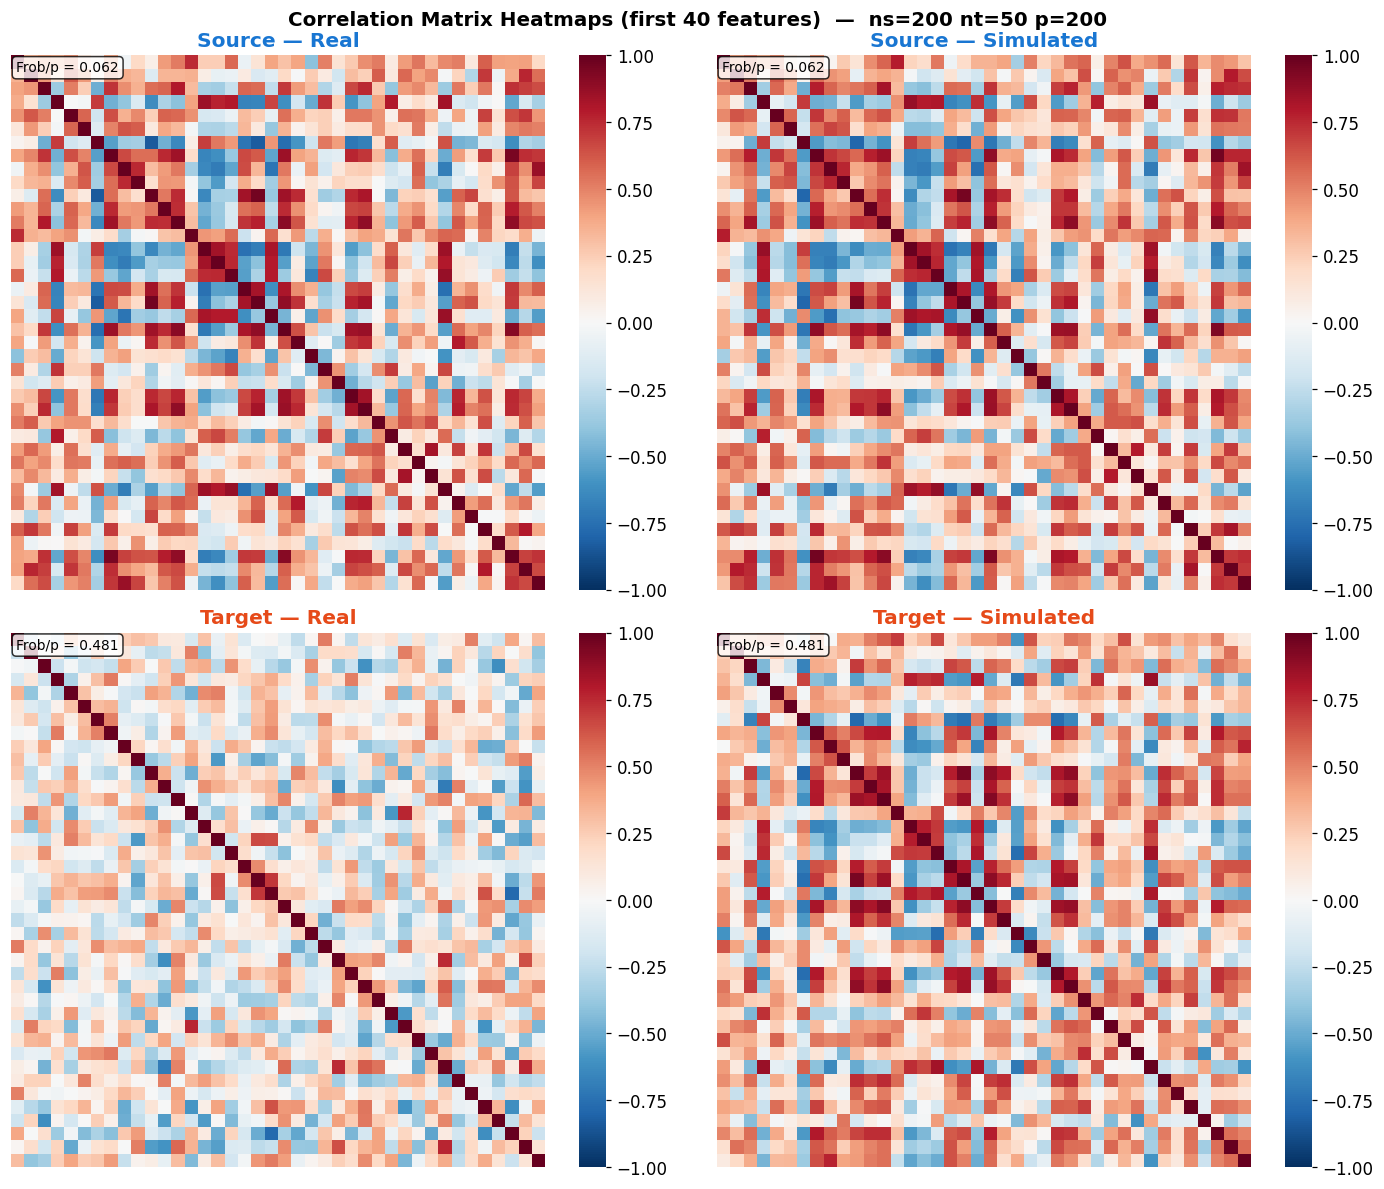

In [11]:
HMAP_FEATS = 40   # show top N features for readability

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle(f"Correlation Matrix Heatmaps (first {HMAP_FEATS} features)  —  {rec['label']}",
             fontsize=13, fontweight='bold')

hmap_kwargs = dict(vmin=-1, vmax=1, cmap="RdBu_r", square=True,
                   xticklabels=False, yticklabels=False, cbar=True)

for row, (domain, s, color) in enumerate(panels):
    nf = min(HMAP_FEATS, s["real_cor"].shape[0])
    for col, (label, mat) in enumerate([
        ("Real",      s["real_cor"][:nf, :nf]),
        ("Simulated", s["sim_cor"] [:nf, :nf]),
    ]):
        ax = axes[row, col]
        sns.heatmap(mat, ax=ax, **hmap_kwargs)
        ax.set_title(f"{domain} — {label}", fontweight='bold', color=color)
        ax.text(0.01, 0.99, f"Frob/p = {s['frob']:.3f}", transform=ax.transAxes,
                fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### KS test: per-feature distributional fidelity

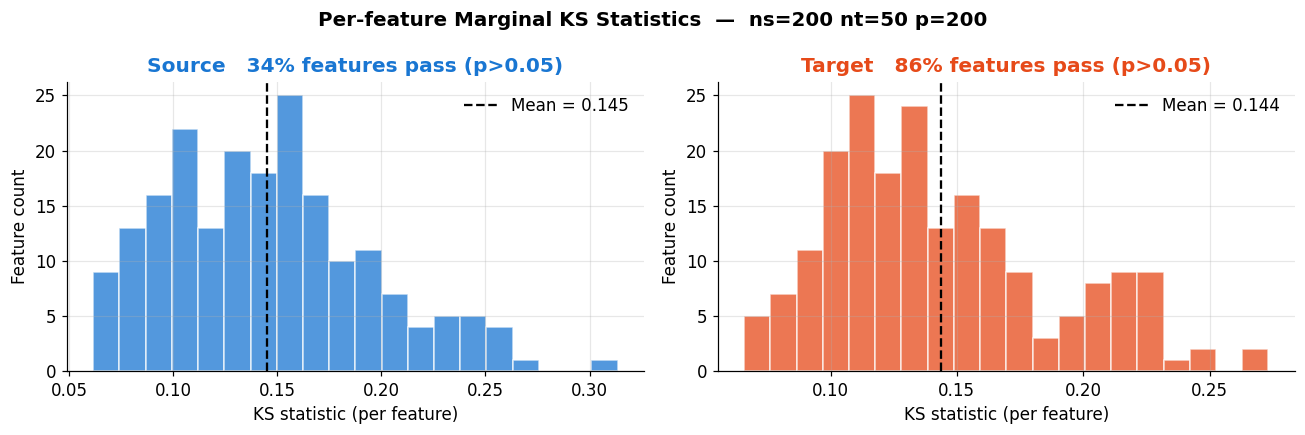

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Per-feature Marginal KS Statistics  —  {rec['label']}",
             fontsize=13, fontweight='bold')

for ax, (domain, s, color) in zip(axes, panels):
    ax.hist(s["ks_stats"], bins=20, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(s["feat_ks_mean"], color='black', lw=1.5, ls='--',
               label=f"Mean = {s['feat_ks_mean']:.3f}")
    ax.set_xlabel("KS statistic (per feature)")
    ax.set_ylabel("Feature count")
    ax.set_title(f"{domain}   {s['frac_pass']*100:.0f}% features pass (p>0.05)",
                 fontweight='bold', color=color)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### PCA alignment: do simulated samples occupy the same latent space?

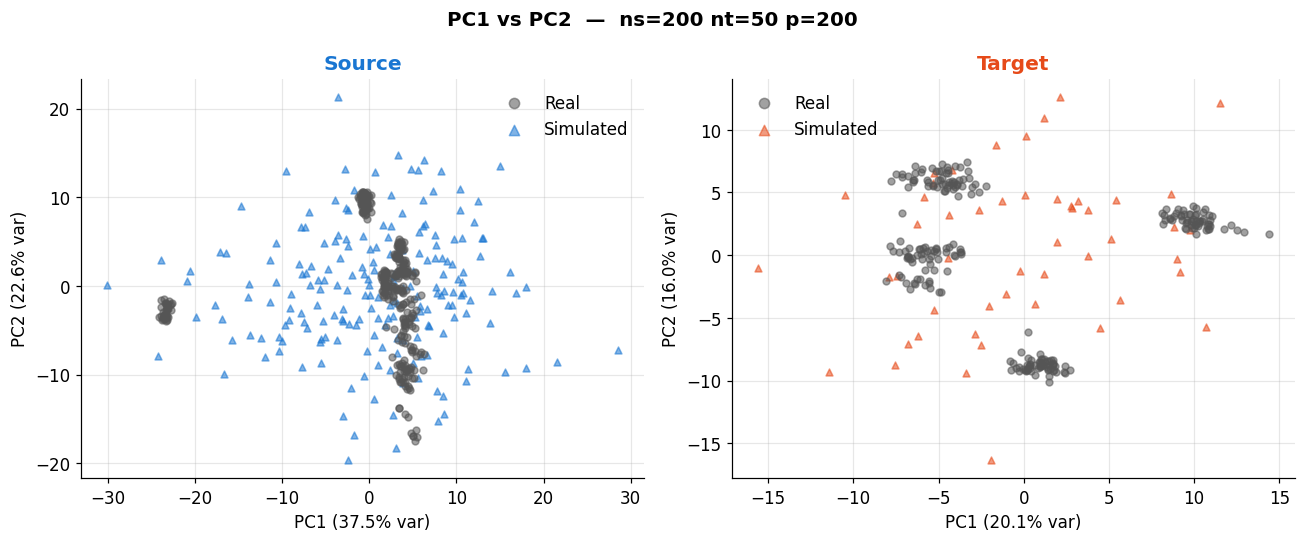

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"PC1 vs PC2  —  {rec['label']}", fontsize=13, fontweight='bold')

for ax, (domain, real_df, sim_df, color) in zip(axes, [
    ("Source", rec["real_src"], rec["synth_src"], PALETTE["source"]),
    ("Target", rec["real_tgt"], rec["synth_tgt"], PALETTE["target"]),
]):
    combined = pd.concat([real_df, sim_df], axis=0)
    labels   = ["Real"] * len(real_df) + ["Simulated"] * len(sim_df)

    scaler = StandardScaler()
    pca    = PCA(n_components=2)
    pcs    = pca.fit_transform(scaler.fit_transform(combined.values))

    n_real = len(real_df)
    ax.scatter(pcs[:n_real, 0], pcs[:n_real, 1],
               color=REAL_COLOR, alpha=0.55, s=20, label="Real", zorder=3)
    ax.scatter(pcs[n_real:, 0], pcs[n_real:, 1],
               color=color, alpha=0.55, s=20, marker='^', label="Simulated", zorder=2)
    var_exp = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% var)")
    ax.set_title(domain, fontweight='bold', color=color)
    ax.legend(frameon=False, markerscale=1.5)

plt.tight_layout()
plt.show()

## How does fidelity change with sample size (n_target)?

We focus on the target domain because source always has large n; target is the
scarce-data setting that the shrinkage estimator is designed to handle.

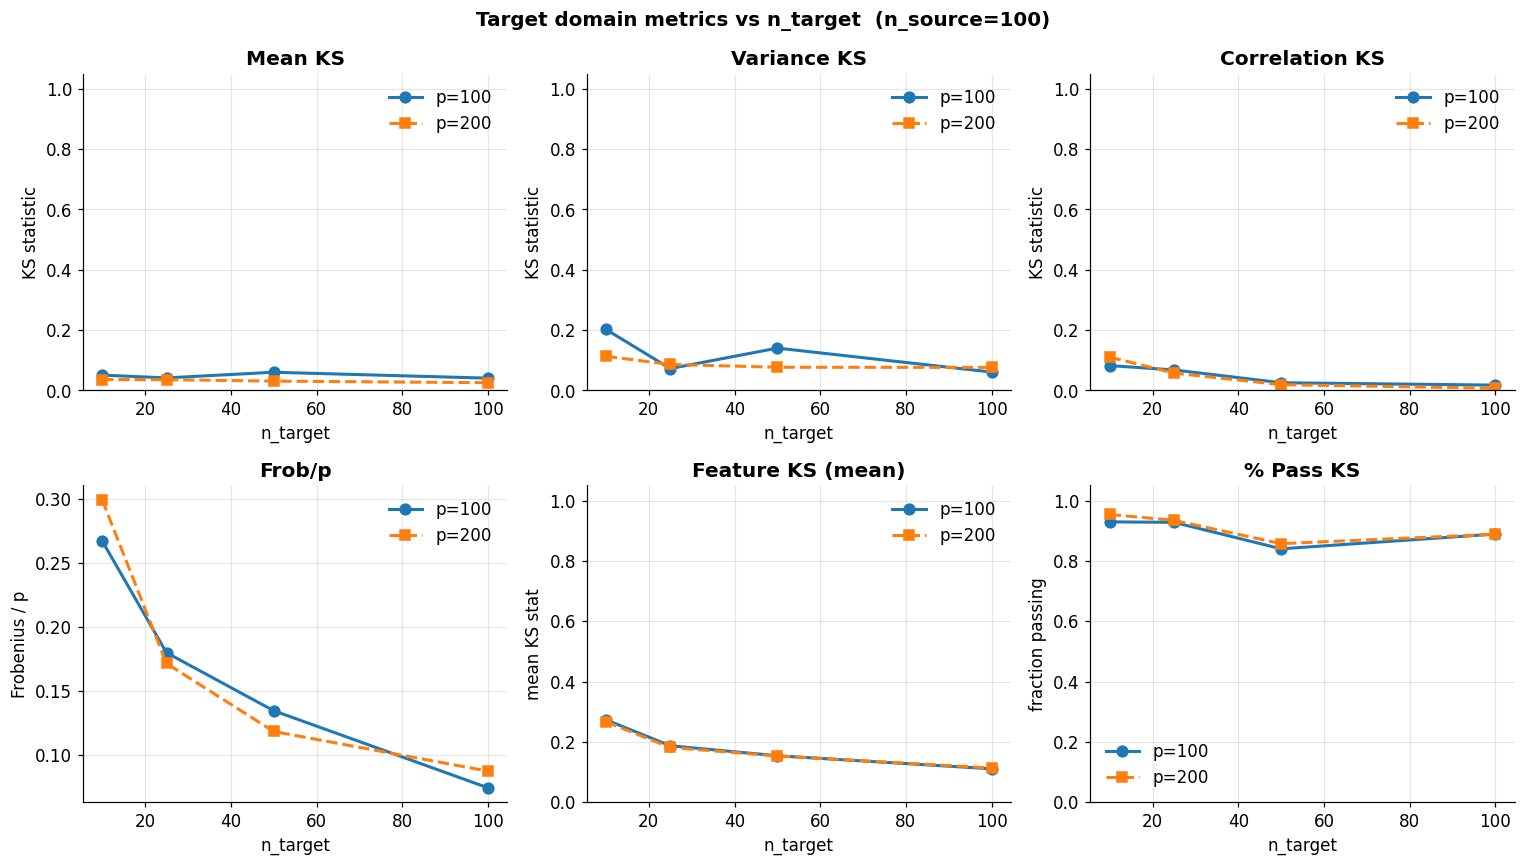

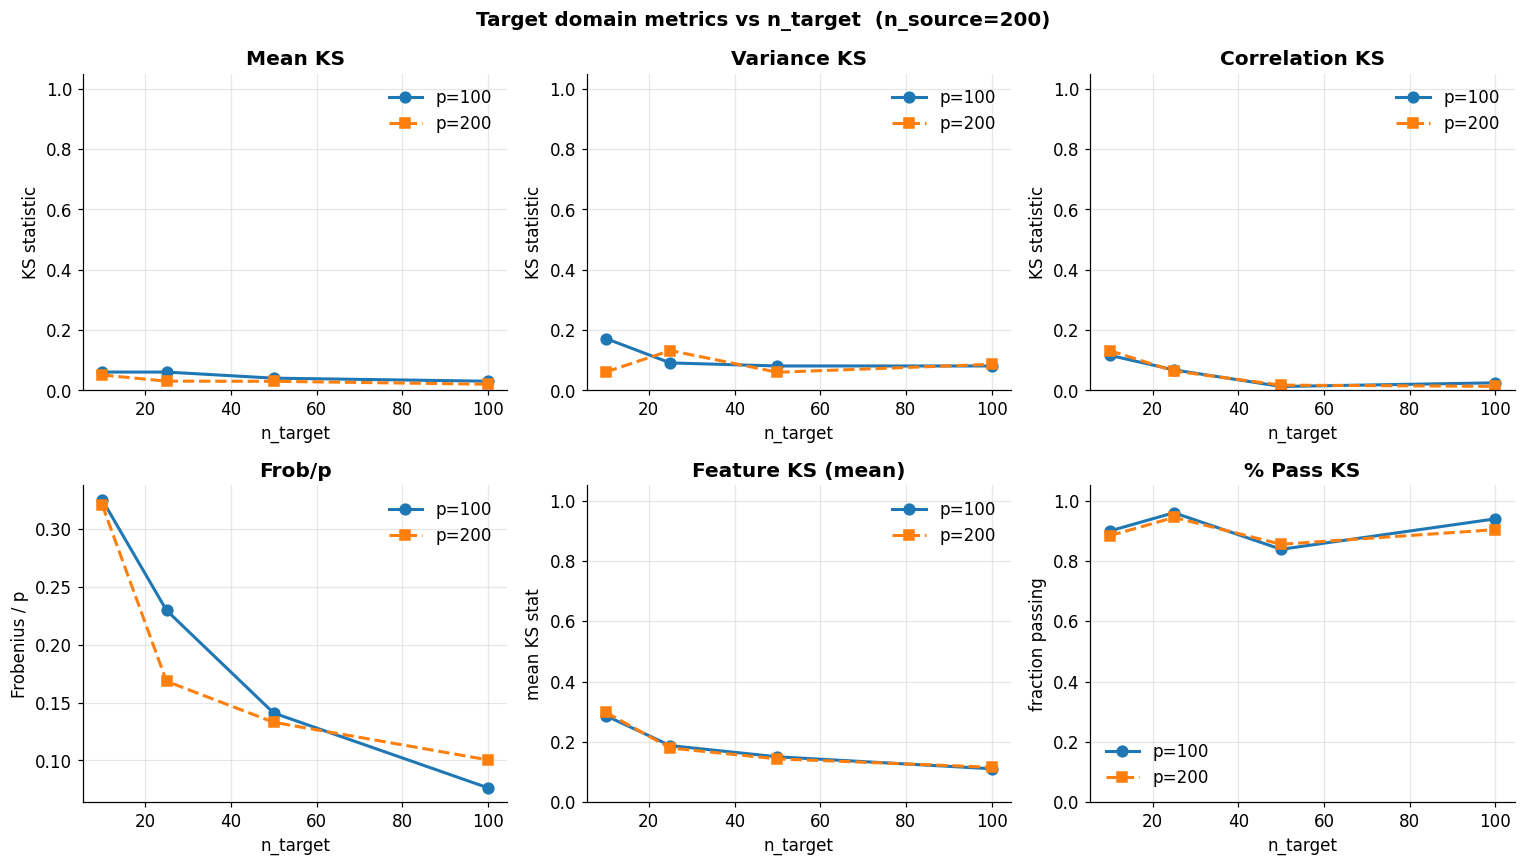

In [13]:
metrics_cfg = [
    ("mean_ks",      "Mean KS",           "KS statistic"),
    ("var_ks",       "Variance KS",       "KS statistic"),
    ("cor_ks",       "Correlation KS",    "KS statistic"),
    ("frob",         "Frob/p",            "Frobenius / p"),
    ("feat_ks_mean", "Feature KS (mean)", "mean KS stat"),
    ("frac_pass",    "% Pass KS",         "fraction passing"),
]

for ns_fixed in n_source_list:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(f"Target domain metrics vs n_target  (n_source={ns_fixed})",
                 fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for ax_idx, (key, title, ylabel) in enumerate(metrics_cfg):
        ax = axes[ax_idx]
        for pf, ls in zip(p_list, ['-o', '--s']):
            sub = [
                r for r in records
                if r["n_source"] == ns_fixed and r["p"] == pf
            ]
            xs = [r["n_target"]          for r in sub]
            ys = [r["tgt_stats"][key]    for r in sub]
            ax.plot(xs, ys, ls, lw=2, ms=7, label=f"p={pf}")
        ax.set_xlabel("n_target")
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight='bold')
        if key in ("mean_ks", "var_ks", "cor_ks", "feat_ks_mean"):
            ax.set_ylim(0, 1.05)
        elif key == "frac_pass":
            ax.set_ylim(0, 1.05)
        ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

## How does fidelity change with feature count (p)?

In [ ]:
for ns_fixed in n_source_list:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(f"Metrics vs p (feature count)  (n_source={ns_fixed})",
                 fontsize=13, fontweight='bold')
    axes = axes.flatten()

    for ax_idx, (key, title, ylabel) in enumerate(metrics_cfg):
        ax = axes[ax_idx]
        for nt, ls in zip(n_target_list, ['-o', '--s', ':^', '-.d']):
            sub = [
                r for r in records
                if r["n_source"] == ns_fixed and r["n_target"] == nt
            ]
            xs = [r["p"]                for r in sub]
            src_ys = [r["src_stats"][key] for r in sub]
            tgt_ys = [r["tgt_stats"][key] for r in sub]
            ax.plot(xs, src_ys, ls, lw=1.5, ms=6, alpha=0.6,
                    color=PALETTE["source"], label=f"Source nt={nt}")
            ax.plot(xs, tgt_ys, ls, lw=1.5, ms=6, alpha=0.9,
                    color=PALETTE["target"], label=f"Target nt={nt}")
        ax.set_xlabel("p (features)")
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight='bold')
        if key in ("mean_ks", "var_ks", "cor_ks", "feat_ks_mean", "frac_pass"):
            ax.set_ylim(0, 1.05)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles[:len(n_target_list)*2], labels[:len(n_target_list)*2],
               loc='lower center', ncol=4, frameon=False,
               bbox_to_anchor=(0.5, -0.02), fontsize=9)

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

## Source vs Target fidelity comparison

Direct comparison of how well each domain is captured across all scenarios.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Source vs Target domain: KS metrics across all scenarios",
             fontsize=13, fontweight='bold')

for ax, (key, title, _) in zip(axes, metrics_cfg[:3]):
    src_vals = [r["src_stats"][key] for r in records]
    tgt_vals = [r["tgt_stats"][key] for r in records]

    sc = ax.scatter(src_vals, tgt_vals, alpha=0.7, s=35,
                    c=[r["n_target"] for r in records],
                    cmap='plasma', edgecolors='none')
    lims = [0, 1.05]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"Source {title}")
    ax.set_ylabel(f"Target {title}")
    ax.set_title(title, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='plasma',
                            norm=plt.Normalize(min(n_target_list), max(n_target_list)))
cbar = fig.colorbar(sm, ax=axes, shrink=0.7, pad=0.02)
cbar.set_label("n_target", fontsize=10)

plt.show()